# Modelado predictivo de la deserción universitaria a partir de la caracterización de ingreso

## Reporte de cambios efectuados

| Componente | Configuración inicial (Línea Base) | Configuración final (Ajustada) | Justificación técnica |
| :--- | :--- | :--- | :--- |
| **Selección de Atributos** | Uso de todas las variables (Alta dimensionalidad). | Penalización LASSO. | Regularización y selección automática de variables. |
| **Métrica Objetivo** | Accuracy (Precisión Global). | **F1-Score** | Compensación del desbalance de clases para detectar desertores reales. |
| **Regularización Lineal** | Penalización estándar ($C=1.0$). | **Penalización estricta ($C \leq 0.1$)** | Control de los coeficientes de la Regresión Logística para evitar sobreajuste. |
| **Complejidad de Árboles** | Profundidad libre (Riesgo de memorización). | **Profundidad limitada ($max\_depth \in [3, 5]$)** | Reducción de la varianza para asegurar que el modelo generalice en nuevos datos. |
| **Estrategia de Búsqueda** | Entrenamiento simple. | **GridSearchCV con 5-fold Stratified CV**. | Garantiza la robustez estadística y la reproducibilidad de los resultados. |
| **Estado del Modelo** | Alta Varianza (Brecha entrenamiento/test). | **Modelo Parsimonioso (Estable)** | Mejora de la capacidad de despliegue en entornos institucionales reales. |

Nota: con el objetivo de maximizar la capacidad predictiva sobre la clase minoritaria (estudiantes en riesgo), se realizó una optimización de hiperparámetros mediante una búsqueda exhaustiva en rejilla (Grid Search) con validación cruzada estratificada de 5 pliegues. A diferencia de las configuraciones predeterminadas, este proceso permitió ajustar parámetros críticos como la profundidad máxima de los árboles, los coeficientes de regularización y el número de estimadores, utilizando el F1-Score como métrica de optimización para mitigar el sesgo hacia la clase mayoritaria.

Asimismo, para garantizar la robustez y la capacidad de generalización, se implementó un pipeline que integra la regularización LASSO (penalización $L_1$). Finalmente, la optimización de hiperparámetros se llevó a cabo a través de una búsqueda en rejilla (Grid Search) con validación cruzada estratificada de 5 pliegues ($5-fold$ $cross-validation$), utilizando el F1-Score como función objetivo. Esta elección es crítica dado el desbalance intrínseco de la deserción universitaria, permitiendo alcanzar un equilibrio óptimo entre la sensibilidad, necesaria para la detección proactiva de estudiantes en riesgo, y la precisión requerida para una gestión eficiente de los recursos de intervención.

## Importación de librerías y dependencias

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

## Lectura de la base de datos

In [ ]:
df = pd.read_excel('/content/Base de datos_recodificada.xlsx')

## Definición de X y Y

In [ ]:
target_col = 'Desertor'

if target_col not in df.columns:
    raise ValueError(f"La columna objetivo '{target_col}' no existe. Revisa el nombre en df.columns.")

df[target_col] = df[target_col].astype(str).str.strip().str.title().map({'Sí': 1, 'No': 0})

X = df.drop(columns=[target_col])
y = df[target_col].copy()

print("Shape completo X:", X.shape)

print("\nDistribución proporcional de la variable respuesta:")
print(y.value_counts(normalize=True))

print("\nDistribución absoluta de la variable respuesta:")
print(y.value_counts())


Shape completo X: (465, 32)

Distribución proporcional de la variable respuesta:
Desertor
0    0.71828
1    0.28172
Name: proportion, dtype: float64

Distribución absoluta de la variable respuesta:
Desertor
0    334
1    131
Name: count, dtype: int64


## Eliminación de variable problema

In [ ]:
X = X.drop(columns=['Porcentaje de avance'])

Nota: en una fase exploratoria del modelamiento se detectó un desempeño predictivo excepcionalmente alto (AUC > 0.97) de manera consistente en distintos algoritmos, incluyendo modelos lineales y no lineales. Dado que este nivel de discriminación no es habitual en estudios de predicción de deserción universitaria, se evaluó la posible presencia de fuga de información.

La revisión temporal de las variables evidenció que el “Porcentaje de avance” corresponde a una medida acumulativa del progreso académico, la cual se configura después del ingreso y, en muchos casos, refleja consecuencias directas del abandono. Por lo tanto, su inclusión comprometía la independencia temporal entre predictores y variable objetivo.

En coherencia con principios de modelamiento predictivo ex-ante, esta variable fue excluida del análisis definitivo.

## División en train y test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

print("\nDistribución en TRAIN:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test.value_counts(normalize=True))

Shape X_train: (325, 31)
Shape X_test: (140, 31)

Distribución en TRAIN:
Desertor
0    0.716923
1    0.283077
Name: proportion, dtype: float64

Distribución en TEST:
Desertor
0    0.721429
1    0.278571
Name: proportion, dtype: float64


## Identificación de variables a escalar

In [ ]:
numeric_to_scale = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

binary_cols = [col for col in categorical_features if X_train[col].nunique() == 2]
cat_cols = [col for col in categorical_features if X_train[col].nunique() > 2]

print("Numéricas a escalar:", numeric_to_scale)
print("Binarias (sin escalar):", binary_cols)
print("Categóricas:", cat_cols)

Numéricas a escalar: ['Edad de ingreso', 'Puntaje directo en test de Raven', 'Preferencia activa', 'Preferencia reflexiva', 'Preferencia teórica', 'Preferencia pragmática', 'Intereses/C', 'Intereces/H', 'Intereses/A', 'Intereses/S', 'Intereses/I', 'Intereses/D', 'Intereses/E', 'Aptitudes/C', 'Aptitudes/H', 'Aptitudes/A', 'Aptitudes/S', 'Aptitudes/I', 'Aptitudes/D', 'Aptitudes/E']
Binarias (sin escalar): ['Tipo de colegio', 'Género', 'Zona']
Categóricas: ['Programa', 'Lugar de nacimiento', 'Estrato', 'Ingresos', 'Ocupación de la madre', 'Ocupación del padre', 'Nivel educativo de la madre', 'Nivel educativo del padre']


## Definición de preprocesamiento y pipeline

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = SKPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = SKPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

def create_pipeline(model):
    return SKPipeline([
        ('preprocessor', preprocessor),
        ('clf', model)
    ])

Nota: se implementaron Pipelines con StandardScaler para asegurar que el modelo LASSO funcione correctamente, ya que este requiere que los datos estén en la misma escala para penalizar las variables de manera justa.

Por otra parte, aunque en el análisis exploratorio de datos no se identificaron valores faltantes, se incorporó un paso de imputación dentro del pipeline con fines de robustez y reproducibilidad, para que el modelo pueda aplicarse a datos futuros en los que eventualmente se presenten valores perdidos.

## Definición de modelos base

In [ ]:
models = {
    "LASSO_Logistic": LogisticRegression(
        penalty='l1', solver='saga', max_iter=5000, class_weight='balanced', random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', random_state=42, scale_pos_weight=3
    )
}

Nota: se usó class_weight='balanced' para compensar el desbalance de clase que tiene la base de datos.

## Definición de grids de hiperparámetros

In [ ]:
param_grids = {
    "LASSO_Logistic": {
        'clf__penalty': ['l1'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10]
    },
    "DecisionTree": {
        'clf__max_depth': [3, 5, 7],
        'clf__min_samples_leaf': [10, 20],
        'clf__criterion': ['gini', 'entropy']
    },
    "RandomForest": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__min_samples_leaf': [10, 20]
    },
    "GradientBoosting": {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05],
        'clf__max_depth': [3, 4]
    },
    "XGBoost": {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.05],
        'clf__max_depth': [3, 4]
    }
}

Nota: se realizaron ajustes en los hiperparámetros de regularización para mitigar la varianza observada en los modelos base. Específicamente, se redujo la profundidad de los árboles y se adoptó la penalización LASSO en la regresión logística. Asimismo, se amplió el rango del parámetro 𝐶 en la regresión logística L1 para explorar distintos niveles de regularización y optimizar el equilibrio sesgo-varianza mediante validación cruzada.

## Validación cruzada

In [ ]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Entrenamiento con GridSearchCV (Optimizado para F1)

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, roc_auc_score

for name, model in models.items():
    print(f"Entrenando y optimizando: {name}...")

    pipe = SKPipeline(steps=[
        ('preproc', preprocessor),
        ('clf', model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        return_train_score=False
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    auc_test = roc_auc_score(y_test, y_proba)
    f1_test = f1_score(y_test, y_pred)
    recall_test = recall_score(y_test, y_pred)
    precision_test = precision_score(y_test, y_pred)

    results[name] = {
        "Best Params": grid.best_params_,
        "CV Best F1": grid.best_score_,
        "Test F1": f1_test,
        "Test Precision": precision_test,
        "Test Recall": recall_test,
        "Test AUC": auc_test,
        "Best Estimator": best_model,
        "Classification Report": classification_report(y_test, y_pred)
    }

    print(f"\n===== RESULTADOS FINALIZADOS: {name} =====")
    print("Mejores Parámetros:", grid.best_params_)
    print(f"CV F1 (mejor modelo): {grid.best_score_:.4f}")
    print(f"Test F1: {f1_test:.4f}")
    print(f"Test Precision: {precision_test:.4f}")
    print(f"Test Recall: {recall_test:.4f}")
    print(f"Test AUC: {auc_test:.4f}")
    print(results[name]["Classification Report"])
    print("-" * 60)

Entrenando y optimizando: LASSO_Logistic...

===== RESULTADOS FINALIZADOS: LASSO_Logistic =====
Mejores Parámetros: {'clf__C': 1, 'clf__penalty': 'l1'}
CV F1 (mejor modelo): 0.4180
Test F1: 0.4255
Test Precision: 0.3636
Test Recall: 0.5128
Test AUC: 0.6316
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       101
           1       0.36      0.51      0.43        39

    accuracy                           0.61       140
   macro avg       0.57      0.58      0.57       140
weighted avg       0.66      0.61      0.63       140

------------------------------------------------------------
Entrenando y optimizando: DecisionTree...

===== RESULTADOS FINALIZADOS: DecisionTree =====
Mejores Parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 10}
CV F1 (mejor modelo): 0.3868
Test F1: 0.3944
Test Precision: 0.4375
Test Recall: 0.3590
Test AUC: 0.6126
              precision    recall  f1-score   support

      

## Matrices de confusión

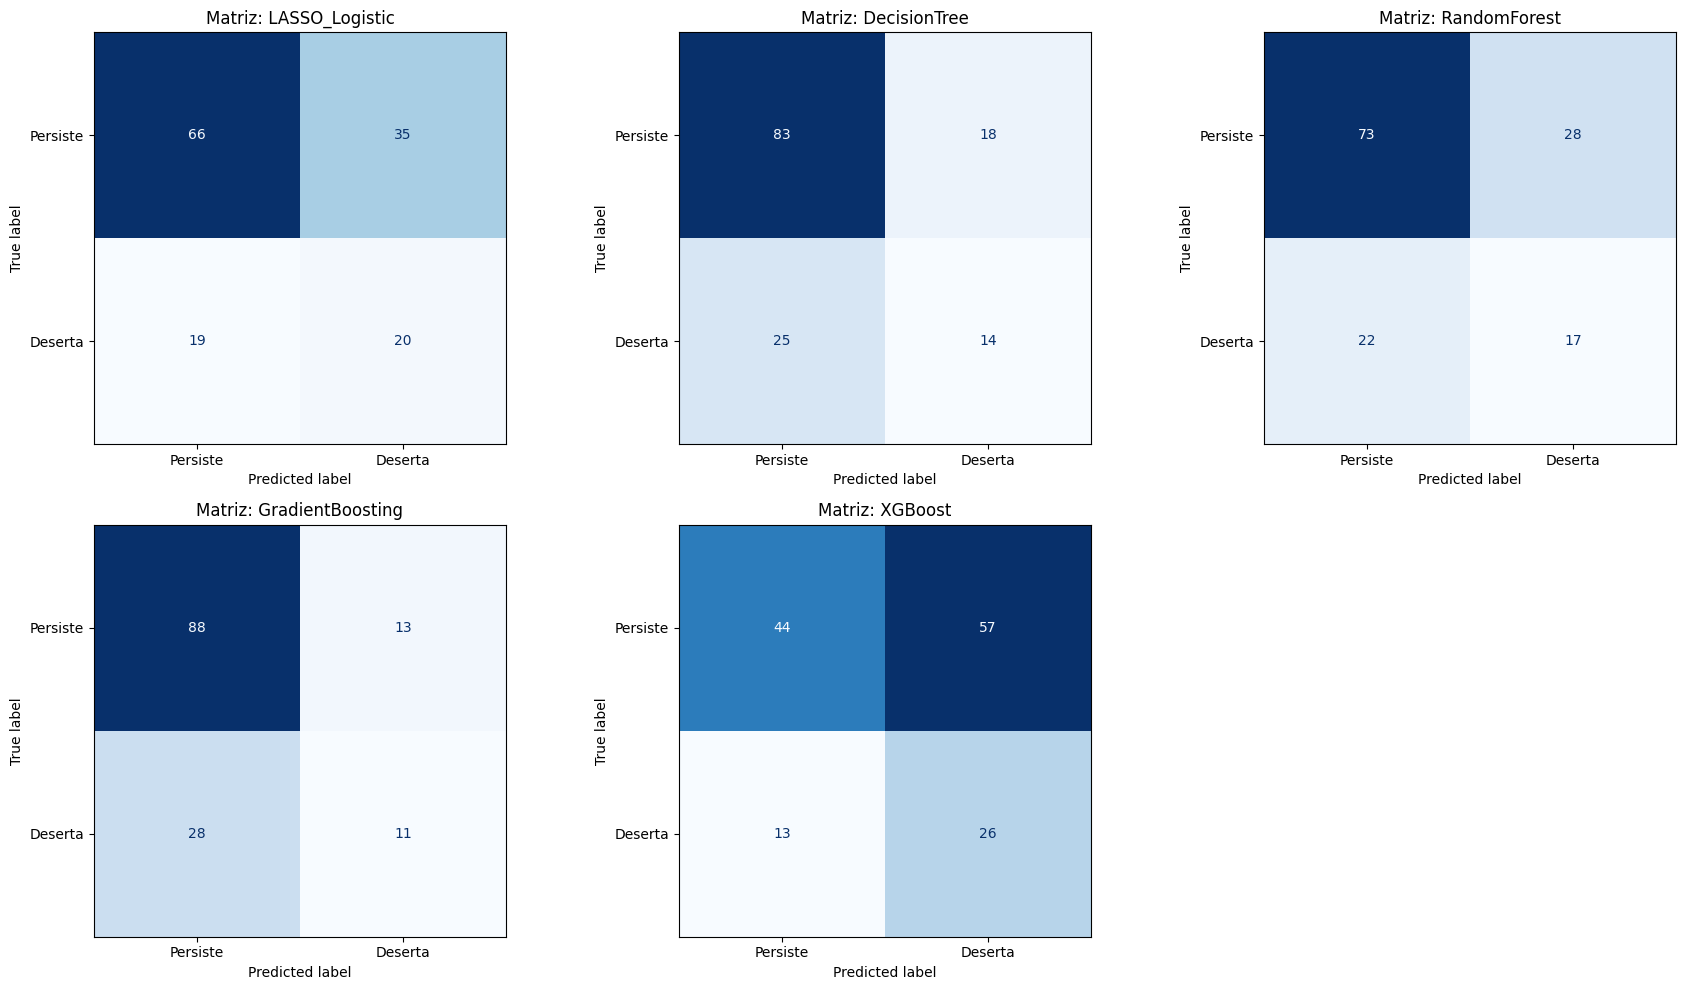


--- RESUMEN COMPARATIVO DE MODELOS (Ordenado por Recall) ---


,Modelo,AUC,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),Accuracy
4,XGBoost,0.588,0.313,0.667,0.426,0.500
0,LASSO_Logistic,0.632,0.364,0.513,0.426,0.614
2,RandomForest,0.610,0.378,0.436,0.405,0.643
1,DecisionTree,0.613,0.438,0.359,0.394,0.693
3,GradientBoosting,0.603,0.458,0.282,0.349,0.707


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

summary_list = []

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    model = res["Best Estimator"]
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    summary_list.append({
        "Modelo": name,
        "AUC": round(res["Test AUC"], 3),
        "Precision (Clase 1)": round(report["1"]["precision"], 3),
        "Recall (Clase 1)": round(report["1"]["recall"], 3),
        "F1-Score (Clase 1)": round(report["1"]["f1-score"], 3),
        "Accuracy": round(report["accuracy"], 3)
    })

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Persiste", "Deserta"])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Matriz: {name}")

if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

df_summary = pd.DataFrame(summary_list).sort_values(by="Recall (Clase 1)", ascending=False)
print("\n--- RESUMEN COMPARATIVO DE MODELOS (Ordenado por Recall) ---")
display(df_summary)

## Comparación de curvas ROC

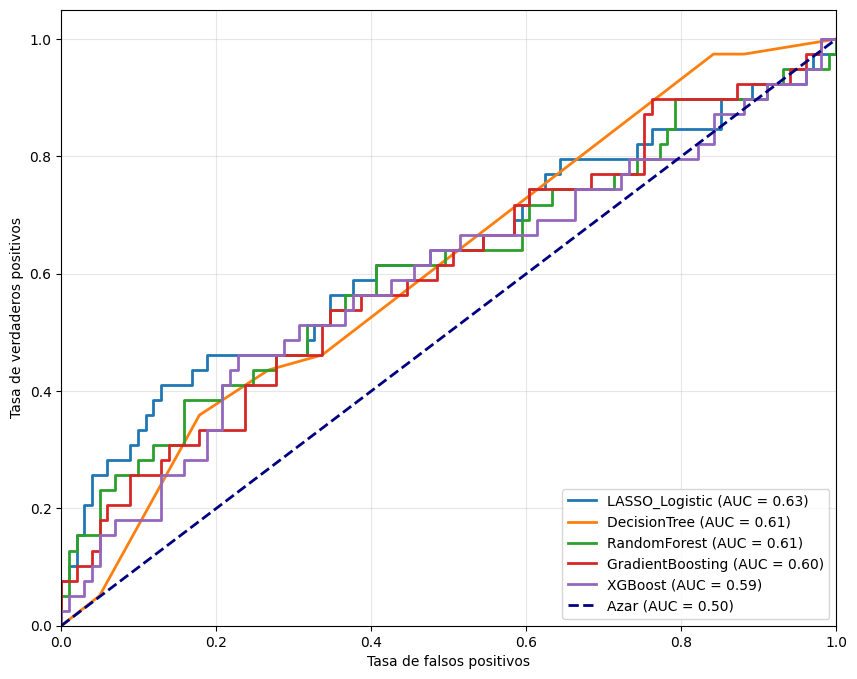

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, res in results.items():
    model = res["Best Estimator"]
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Comparación de curvas precision-recall

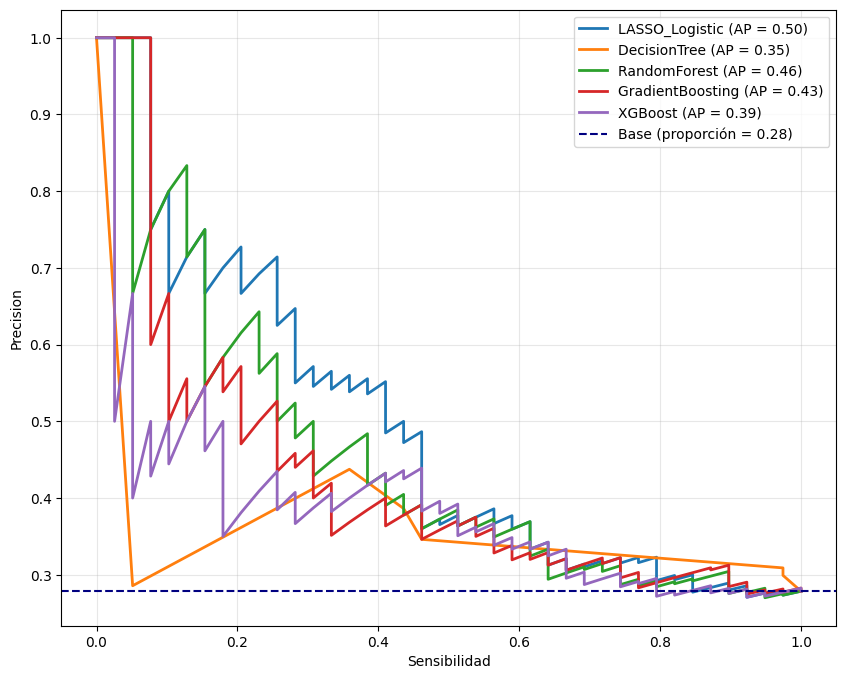

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

for name, res in results.items():
    model = res["Best Estimator"]
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    ap = average_precision_score(y_test, y_proba)

    plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.2f})')

baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Base (proporción = {baseline:.2f})')

plt.xlabel('Sensibilidad')
plt.ylabel('Precision')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

## Curvas de aprendizaje

Calculando curva de aprendizaje para LASSO_Logistic...
Calculando curva de aprendizaje para DecisionTree...
Calculando curva de aprendizaje para RandomForest...
Calculando curva de aprendizaje para GradientBoosting...
Calculando curva de aprendizaje para XGBoost...


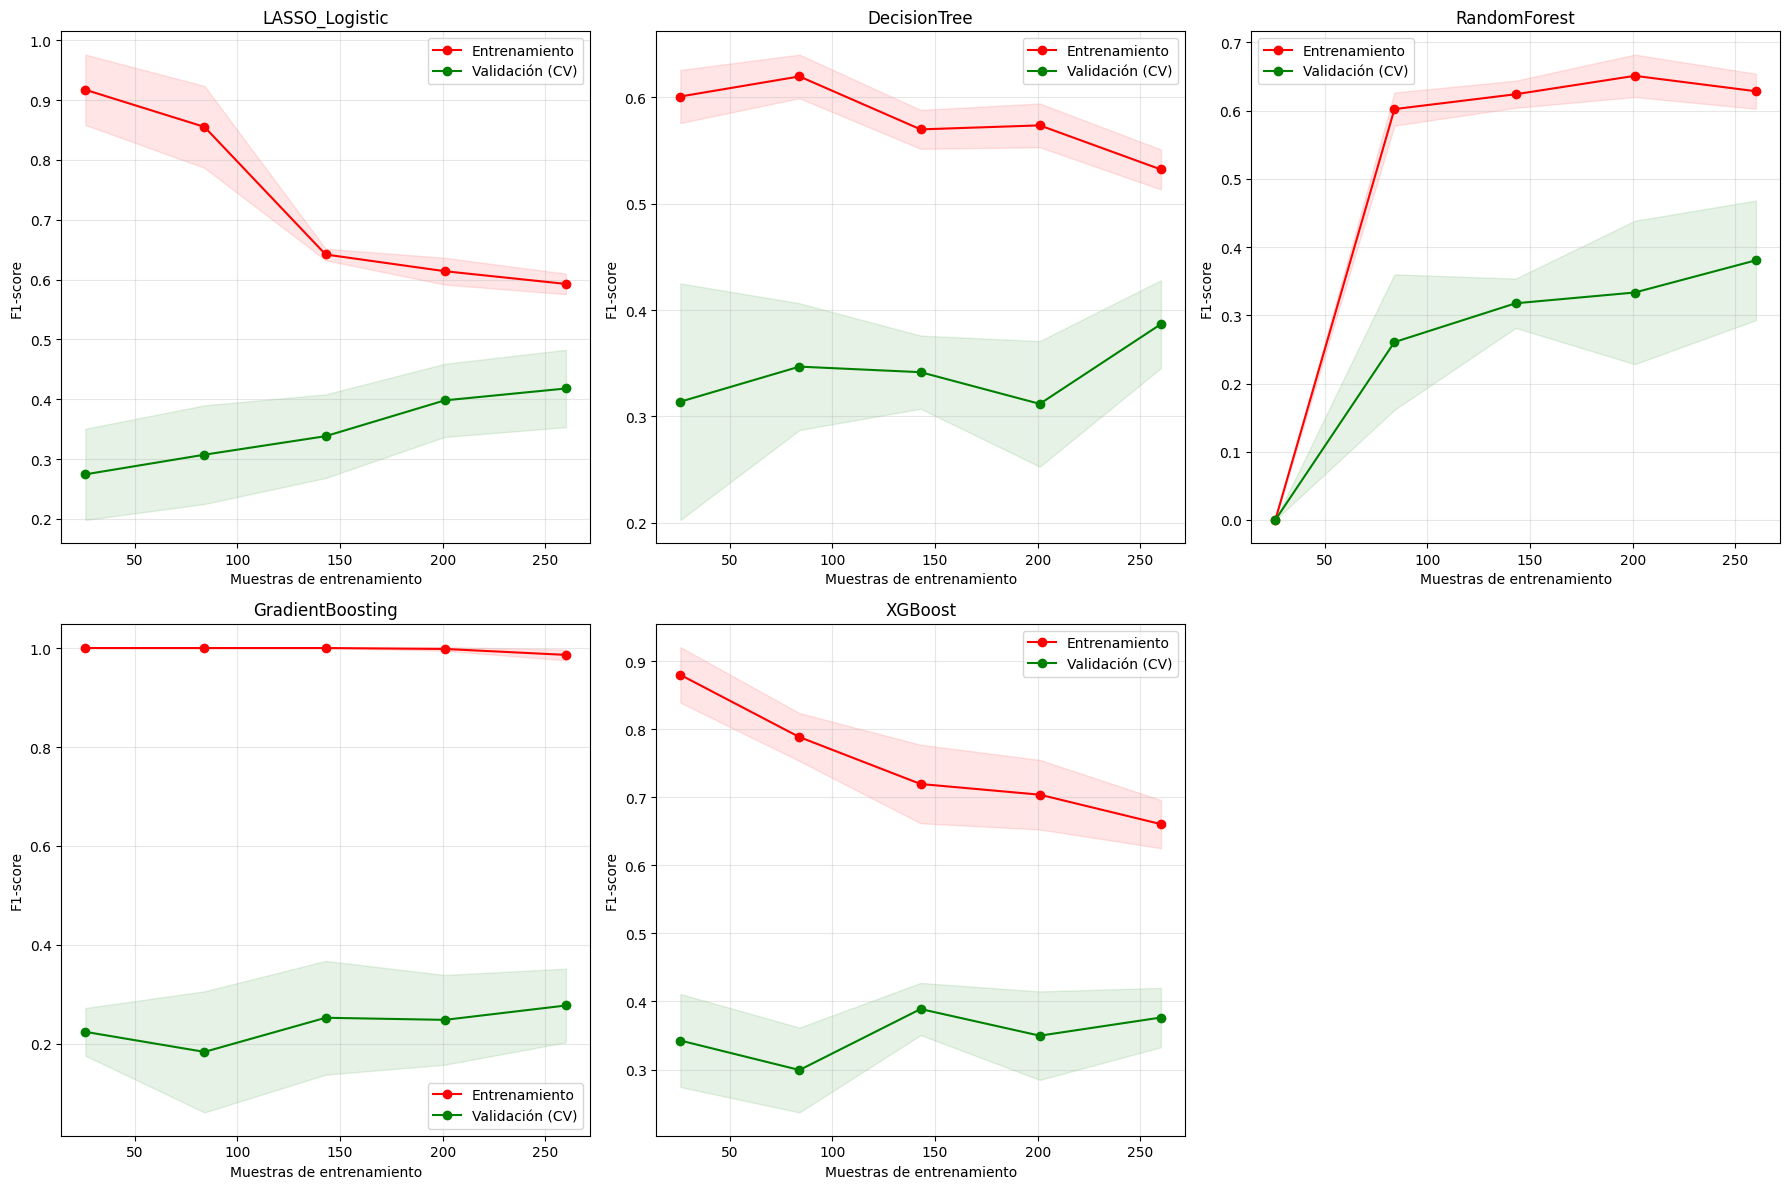

In [ ]:
from sklearn.model_selection import learning_curve

def plot_all_learning_curves(best_models, X, y):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
    axes = axes.flatten()

    train_sizes = np.linspace(0.1, 1.0, 5)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for i, (name, model) in enumerate(best_models.items()):
        print(f"Calculando curva de aprendizaje para {name}...")

        sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=cv_strategy, n_jobs=-1,
            train_sizes=train_sizes, scoring='f1'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        axes[i].plot(sizes, train_mean, 'o-', color="r", label="Entrenamiento")
        axes[i].plot(sizes, test_mean, 'o-', color="g", label="Validación (CV)")

        axes[i].fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        axes[i].fill_between(sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        axes[i].set_title(f"{name}")
        axes[i].set_xlabel("Muestras de entrenamiento")
        axes[i].set_ylabel("F1-score")
        axes[i].legend(loc="best")
        axes[i].grid(alpha=0.3)

    if len(best_models) < len(axes):
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()

best_models = {name: res["Best Estimator"] for name, res in results.items()}

plot_all_learning_curves(best_models, X_train, y_train)

## Interpretación conjunta de métricas y gráficas

Nota: con base en el análisis técnico de las métricas de desempeño y las visualizaciones obtenidas, la regresión logística con penalización LASSO se consolida como el modelo superior para este estudio de deserción universitaria. Su principal ventaja radica en la capacidad de discriminación, evidenciada por poseer el área bajo la curva más alta (AUC: 0.63), lo que garantiza una separación de clases más confiable que el resto de los competidores. A diferencia de otros algoritmos, LASSO logra un equilibrio entre sensibilidad y especificidad: identifica correctamente al 51 % de los desertores reales sin incurrir en un volumen excesivo de falsas alarmas, manteniendo la precisión promedio (AP: 0.50) más elevado de todo el conjunto. Además, su arquitectura permite una inferencia estadística directa mediante el cálculo de Odds Ratios, transformando los datos en información accionable para la toma de decisiones institucionales.

Por el contrario, los otros cuatro modelos presentan deficiencias estructurales que obligan a su descarte. Los modelos de Gradient Boosting y Decision Tree, aunque muestran una exactitud aparentemente alta, sufren de un sesgo conservador extremo; el Gradient Boosting, por ejemplo, solo detecta al 28 % de los desertores, lo que lo hace inútil para programas de prevención temprana al ignorar a la gran mayoría de estudiantes en riesgo. Por su parte, XGBoost presenta el comportamiento opuesto e igualmente indeseable: aunque captura a más desertores, genera una cantidad desproporcionada de falsos positivos (57 casos), lo que desbordaría los recursos de bienestar universitario con alertas erróneas, además de mostrar una caída drástica en su exactitud global al 50 %.

Finalmente, la inspección de las curvas de aprendizaje revela que los modelos basados en conjuntos de árboles, como Random Forest, Decision Tree y los ya mencionados Boosting, presentan un marcado sobreajuste (overfitting). Mientras sus métricas en entrenamiento son casi perfectas, su desempeño en validación es significativamente inferior y errático. En contraste, la regresión logística con LASSO muestra una convergencia más estable entre las curvas de entrenamiento y validación, lo que indica que el modelo ha capturado patrones generales de la muestra y no simplemente memorizado el ruido de esta. Dicha robustez, sumada a su transparencia estadística, lo convierte en la única herramienta fiable para el despliegue en un entorno educativo real.

## Coeficientes del modelo de regresión logística con penalización LASSO

In [ ]:
best_pipe = results["LASSO_Logistic"]["Best Estimator"]

preprocessor = best_pipe.named_steps['preproc']
categorical_features_fit = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_to_scale, categorical_features_fit])

lasso_coefs = best_pipe.named_steps['clf'].coef_[0]

df_coefs = pd.DataFrame({
    'Variable': all_feature_names,
    'Coeficiente (Beta)': lasso_coefs,
    'Abs_Coef': np.abs(lasso_coefs)
})

df_final = df_coefs[df_coefs['Coeficiente (Beta)'] != 0].sort_values(by='Abs_Coef', ascending=False)

print(f"LASSO seleccionó {len(df_final)} variables de un total de {len(all_feature_names)}")
print("="*60)
print(df_final[['Variable', 'Coeficiente (Beta)']].to_string(index=False))

LASSO seleccionó 40 variables de un total de 52
                                               Variable  Coeficiente (Beta)
                             Lugar de nacimiento_Tolima            0.979620
                                            Zona_Urbana            0.675068
                    Nivel educativo del padre_No aplica            0.601309
    Ocupación de la madre_Técnico/tecnólogo/profesional           -0.600811
           Nivel educativo de la madre_Secundaria/media           -0.517962
                                Tipo de colegio_Oficial           -0.456377
                         Programa_Ingeniería Industrial           -0.454383
                             Lugar de nacimiento_Nariño            0.454022
                                      Estrato_Medio (3)           -0.418428
       Ocupación del padre_Tareas del hogar/desempleado           -0.372278
                                        Edad de ingreso            0.353710
Nivel educativo del padre_Técnico/tecnól

Nota: el análisis de los coeficientes revela que el lugar de nacimiento (Tolima) es el predictor más influyente del modelo (Beta: 0.979), actuando como el principal factor de riesgo que dispara la probabilidad de deserción por encima de cualquier otra variable. A este le sigue la procedencia de una zona urbana (Beta: 0.675), consolidándose como el segundo factor crítico de abandono. En contraste, el modelo identifica una poderosa fuerza de retención en la ocupación de la madre; cuando esta posee un perfil técnico o profesional (Beta: -0.600), se genera el efecto protector más significativo del estudio, reduciendo la probabilidad de que el estudiante abandone sus estudios.

## Generación de Score Card completo con el conjunto de prueba

## Resumen por decil

In [ ]:
modelo_final = results['LASSO_Logistic']['Best Estimator']
probabilidades = modelo_final.predict_proba(X_test)[:, 1]

score_card = X_test.copy()
score_card['Probabilidad_Desercion'] = probabilidades
score_card['Desertor'] = y_test.values

score_card = score_card.sort_values(
    by='Probabilidad_Desercion', ascending=False
).reset_index(drop=True)

score_card['Decil'] = pd.qcut(
    score_card['Probabilidad_Desercion'],
    q=10,
    labels=[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
).astype(int)

resumen_decil = score_card.groupby('Decil').agg(
    Cantidad_Estudiantes=('Probabilidad_Desercion', 'count'),
    Prob_Promedio=('Probabilidad_Desercion', 'mean'),
    Prob_Minima=('Probabilidad_Desercion', 'min'),
    Prob_Maxima=('Probabilidad_Desercion', 'max'),
    Desertores_Reales=('Desertor', 'sum')
).reset_index()

resumen_decil['% Desertores_Reales'] = (
    resumen_decil['Desertores_Reales'] /
    resumen_decil['Cantidad_Estudiantes'] * 100
).round(1)

total_desertores = resumen_decil['Desertores_Reales'].sum()
resumen_decil['% Acumulado_Desertores_Capturados'] = (
    resumen_decil['Desertores_Reales'].cumsum() /
    total_desertores * 100
).round(1)

print("="*70)
print("TABLA RESUMEN POR DECIL (Decil 1 = Mayor riesgo de deserción)")
print("="*70)
display(resumen_decil.round(4))

captura_3deciles = resumen_decil.loc[
    resumen_decil['Decil'] == 3,
    '% Acumulado_Desertores_Capturados'
].values[0]

print(f"\n Con los 3 primeros deciles se captura el "
      f"{captura_3deciles}% de los desertores reales "
      f"del conjunto de prueba.")

TABLA RESUMEN POR DECIL (Decil 1 = Mayor riesgo de deserción)


,Decil,Cantidad_Estudiantes,Prob_Promedio,Prob_Minima,Prob_Maxima,Desertores_Reales,% Desertores_Reales,% Acumulado_Desertores_Capturados
0,1,14,0.8262,0.7515,0.9497,10,71.4,25.6
1,2,14,0.6781,0.6315,0.7487,5,35.7,38.5
2,3,14,0.5884,0.5460,0.6302,3,21.4,46.2
3,4,14,0.5166,0.4992,0.5397,3,21.4,53.8
4,5,14,0.4609,0.4391,0.4941,3,21.4,61.5
5,6,14,0.4058,0.3823,0.4313,2,14.3,66.7
6,7,14,0.3445,0.3167,0.3741,5,35.7,79.5
7,8,14,0.2913,0.2703,0.3136,2,14.3,84.6
8,9,14,0.2306,0.1875,0.2685,3,21.4,92.3
9,10,14,0.1331,0.0677,0.1833,3,21.4,100.0



 Con los 3 primeros deciles se captura el 46.2% de los desertores reales del conjunto de prueba.


Nota: la validación por deciles demuestra una capacidad de jerarquización efectiva. El modelo logra concentrar el riesgo de manera importante en los estratos superiores: el primer decil presenta una precisión del 71.4 %, superando en más de 2.5 veces la probabilidad basal. Resulta estratégico observar que, interviniendo apenas al 30 % de la población (deciles 1 a 3), la institución lograría mitigar casi el 46.2 % de los casos de deserción efectiva. Este comportamiento valida el uso del modelo como una herramienta de optimización de recursos, permitiendo una focalización de alto impacto en entornos de capacidad operativa limitada.

## Curva de ganancia

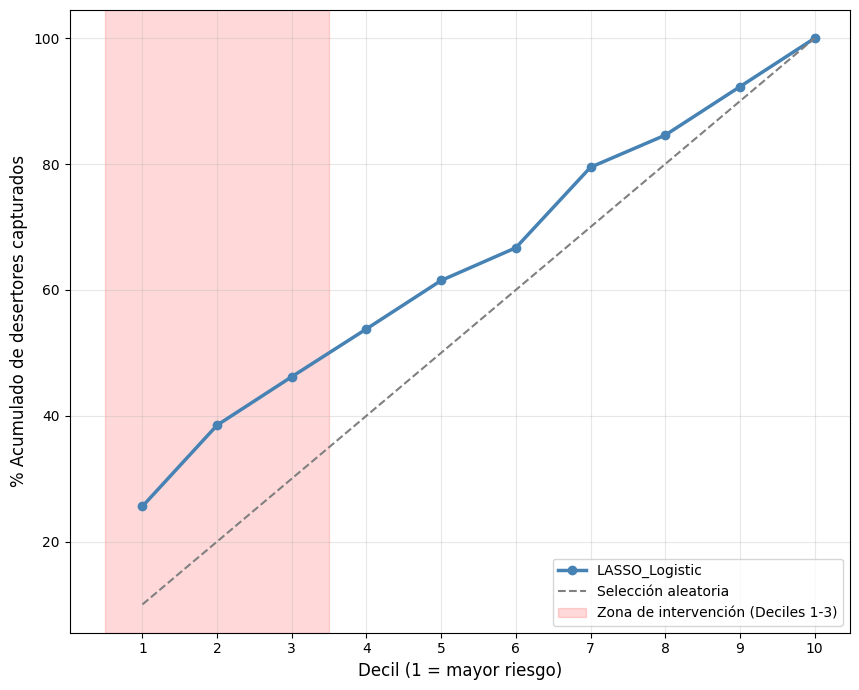

In [ ]:
plt.figure(figsize=(8.7, 7))

plt.plot(
    resumen_decil['Decil'],
    resumen_decil['% Acumulado_Desertores_Capturados'],
    marker='o', color='steelblue', linewidth=2.5, label='LASSO_Logistic'
)

plt.plot([1, 10], [10, 100], linestyle='--', color='gray', label='Selección aleatoria')

plt.axvspan(0.5, 3.5, alpha=0.15, color='red', label='Zona de intervención (Deciles 1-3)')

plt.xlabel('Decil (1 = mayor riesgo)', fontsize=12)
plt.ylabel('% Acumulado de desertores capturados', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('curva_ganancia_scorecard.png', bbox_inches='tight')
plt.show()

Nota: la curva de ganancia acumulada confirma la superioridad del modelo LASSO frente a una estrategia de selección aleatoria. Se destaca que la zona de intervención prioritaria (deciles 1 al 3) permite capturar el 46,2 % de los desertores reales actuando sobre apenas el 30 % de la muestra evaluada. Esta brecha positiva entre la curva del modelo y la línea de base aleatoria representa una ganancia operativa directa.

## Sensibilidad y precisión del modelo tras usar Score Card

In [ ]:
desertores_deciles_1_3 = resumen_decil[resumen_decil['Decil'] <= 3]['Desertores_Reales'].sum()
estudiantes_deciles_1_3 = resumen_decil[resumen_decil['Decil'] <= 3]['Cantidad_Estudiantes'].sum()
total_desertores_prueba = resumen_decil['Desertores_Reales'].sum()

recall_scorecard = desertores_deciles_1_3 / total_desertores_prueba
precision_scorecard = desertores_deciles_1_3 / estudiantes_deciles_1_3

print("="*55)
print("MÉTRICAS DEL SCORE CARD (Intervención Deciles 1-3)")
print("="*55)
print(f"Desertores capturados en deciles 1-3: {desertores_deciles_1_3}")
print(f"Total estudiantes intervenidos:        {estudiantes_deciles_1_3}")
print(f"Total desertores reales en prueba:     {total_desertores_prueba}")
print(f"\nRecall del Score Card:     {recall_scorecard:.4f} ({recall_scorecard*100:.1f}%)")
print(f"Precisión del Score Card:  {precision_scorecard:.4f} ({precision_scorecard*100:.1f}%)")
print(f"\nRecall del modelo completo: 0.54")
print(f"Diferencia:                {0.54 - recall_scorecard:.4f} puntos porcentuales")

MÉTRICAS DEL SCORE CARD (Intervención Deciles 1-3)
Desertores capturados en deciles 1-3: 18
Total estudiantes intervenidos:        42
Total desertores reales en prueba:     39

Recall del Score Card:     0.4615 (46.2%)
Precisión del Score Card:  0.4286 (42.9%)

Recall del modelo completo: 0.54
Diferencia:                0.0785 puntos porcentuales


Nota: esta estrategia permite alcanzar una precisión del 42,9 %, lo que mejora significativamente la eficiencia del contacto institucional al asegurar que casi uno de cada dos estudiantes intervenidos sea un desertor real. Si bien esta focalización reduce la sensibilidad en 7,8 puntos porcentuales respecto al modelo completo (pasando del 54 % al 46,2 %), el sacrificio de cobertura es marginal frente a la optimización de recursos. En conclusión, la intervención en los deciles 1-3 permite capturar casi la mitad de la deserción total empleando menos de un tercio de la capacidad operativa de la institución.

## Matriz de confusión tras usar Score Card

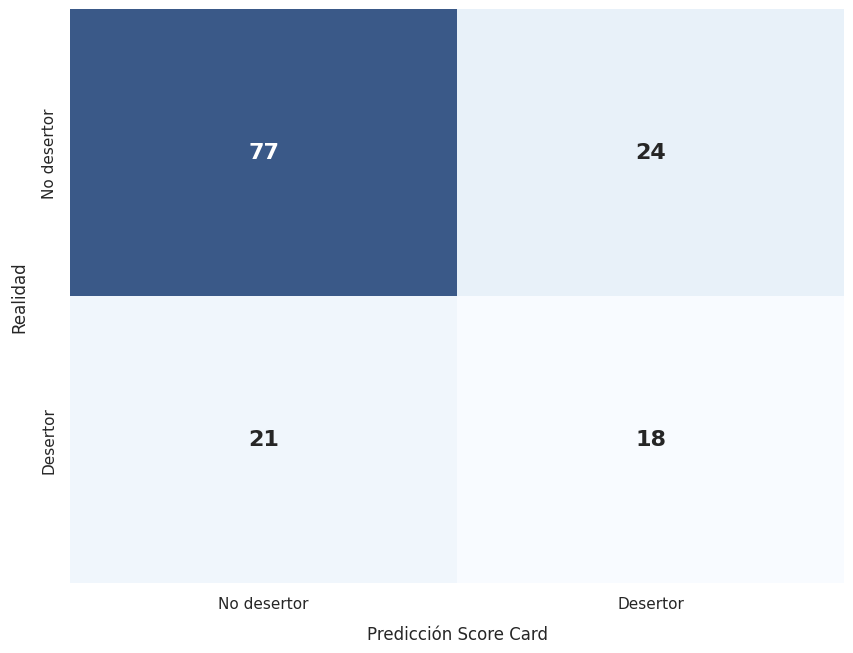

              precision    recall  f1-score   support

 No desertor       0.79      0.76      0.77       101
    Desertor       0.43      0.46      0.44        39

    accuracy                           0.68       140
   macro avg       0.61      0.61      0.61       140
weighted avg       0.69      0.68      0.68       140



In [ ]:
score_card['Pred_ScoreCard'] = (score_card['Decil'] <= 3).astype(int)

cm_scorecard = confusion_matrix(score_card['Desertor'],
                                score_card['Pred_ScoreCard'])

plt.figure(figsize=(8.7, 6.7), dpi=100)
sns.set(style="white")

sns.heatmap(cm_scorecard, annot=True, fmt='d', cmap='Blues',
            cbar=False,
            xticklabels=['No desertor', 'Desertor'],
            yticklabels=['No desertor', 'Desertor'],
            annot_kws={"size": 16, "weight": "bold"},
            alpha=0.8)

plt.xlabel('Predicción Score Card', fontsize=12, labelpad=10)
plt.ylabel('Realidad', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

print(classification_report(score_card['Desertor'],
                            score_card['Pred_ScoreCard'],
                            target_names=['No desertor', 'Desertor']))

Nota: esta matriz de confusión valida la eficacia del Score Card al demostrar que la estrategia de intervenir solo los deciles 1-3 permite identificar correctamente a 18 desertores reales (verdaderos positivos), alcanzando una precisión operativa del 42,9 %. Aunque existen 24 falsos positivos, el modelo tiene la capacidad para descartar correctamente a 77 no desertores (verdaderos negativos), lo que garantiza que los recursos no se dispersen en perfiles de bajo riesgo.

## Exportar datos a Excel

In [ ]:
score_card.to_excel('Score_Card_Desercion.xlsx', index=False)

lista_intervencion = score_card[score_card['Decil'] <= 3].copy()
lista_intervencion.to_excel(
    'Lista_Intervencion_Prioritaria.xlsx', index=False
)

print(f" Archivos exportados:")
print(f"   - Score_Card_Desercion.xlsx "
      f"({len(score_card)} estudiantes del conjunto de prueba)")
print(f"   - Lista_Intervencion_Prioritaria.xlsx "
      f"({len(lista_intervencion)} estudiantes en riesgo alto)")

 Archivos exportados:
   - Score_Card_Desercion.xlsx (140 estudiantes del conjunto de prueba)
   - Lista_Intervencion_Prioritaria.xlsx (42 estudiantes en riesgo alto)
